In [ ]:
# SEQC

# !pip -q install transformers datasets evaluate scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Libraries loaded for SEQC approach.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
Libraries loaded for SEQC approach.


In [ ]:
# load dataset and prepare input text + labels

import pandas as pd

train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def build_seqc_input(row):
    src = safe_text(row["text_src"])
    tgt = safe_text(row["text_tgt"])

    if src and tgt:
        return src + " [SEP] " + tgt
    elif src:
        return src
    else:
        return tgt

train_df["input_text"] = train_df.apply(build_seqc_input, axis=1)
val_df["input_text"] = val_df.apply(build_seqc_input, axis=1)
test_df["input_text"] = test_df.apply(build_seqc_input, axis=1)

labels = train_df["label"].unique()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)
val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nLabel mapping:")
print(label2id)

print("\nSample input:")
print(train_df["input_text"].iloc[0])

print("\nSample label:")
print(train_df["label"].iloc[0], "->", train_df["label_id"].iloc[0])

Train shape: (7478, 10)
Validation shape: (1776, 10)
Test shape: (2312, 10)

Label mapping:
{'Fact/Evidence': 0, 'Grammar': 1, 'Clarity': 2, 'Claim': 3, 'Other': 4}

Sample input:
For MBTI, users were able to provide multiple texts, we report unique users in parentheses.

Sample label:
Fact/Evidence -> 0


In [ ]:
# convert pandas dataframes to Hugging Face datasets

from datasets import Dataset

train_seqc = Dataset.from_pandas(train_df[["input_text", "label_id"]])
val_seqc = Dataset.from_pandas(val_df[["input_text", "label_id"]])
test_seqc = Dataset.from_pandas(test_df[["input_text", "label_id"]])

print("Train dataset:", train_seqc)
print("Validation dataset:", val_seqc)
print("Test dataset:", test_seqc)

Train dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 7478
})
Validation dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 1776
})
Test dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 2312
})


In [ ]:
#  load tokenizer and sequence classification model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

seqc_model_name = "distilbert-base-uncased"

seqc_tokenizer = AutoTokenizer.from_pretrained(seqc_model_name)

seqc_model = AutoModelForSequenceClassification.from_pretrained(
    seqc_model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

print("SEQC model loaded successfully:", seqc_model_name)
print("Number of labels:", len(label2id))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


SEQC model loaded successfully: distilbert-base-uncased
Number of labels: 5


In [ ]:
#  tokenize the datasets

max_length = 128

def tokenize_seqc(example):
    return seqc_tokenizer(
        example["input_text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

train_seqc_tokenized = train_seqc.map(tokenize_seqc, batched=True)
val_seqc_tokenized = val_seqc.map(tokenize_seqc, batched=True)
test_seqc_tokenized = test_seqc.map(tokenize_seqc, batched=True)

print("SEQC tokenization completed.")
print(train_seqc_tokenized[0])

Map:   0%|          | 0/7478 [00:00<?, ? examples/s]

Map:   0%|          | 0/1776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2312 [00:00<?, ? examples/s]

SEQC tokenization completed.
{'input_text': 'For MBTI, users were able to provide multiple texts, we report unique users in parentheses.', 'label_id': 0, 'input_ids': [101, 2005, 16914, 3775, 1010, 5198, 2020, 2583, 2000, 3073, 3674, 6981, 1010, 2057, 3189, 4310, 5198, 1999, 27393, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# set format and rename labels

train_seqc_tokenized = train_seqc_tokenized.rename_column("label_id", "labels")
val_seqc_tokenized = val_seqc_tokenized.rename_column("label_id", "labels")
test_seqc_tokenized = test_seqc_tokenized.rename_column("label_id", "labels")

columns = ["input_ids", "attention_mask", "labels"]

train_seqc_tokenized.set_format(type="torch", columns=columns)
val_seqc_tokenized.set_format(type="torch", columns=columns)
test_seqc_tokenized.set_format(type="torch", columns=columns)

print("SEQC dataset ready for training.")
print(train_seqc_tokenized[0])

SEQC dataset ready for training.
{'labels': tensor(0), 'input_ids': tensor([  101,  2005, 16914,  3775,  1010,  5198,  2020,  2583,  2000,  3073,
         3674,  6981,  1010,  2057,  3189,  4310,  5198,  1999, 27393,  1012,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,    

In [ ]:
# define metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_seqc_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("SEQC metrics function ready.")

SEQC metrics function ready.


In [ ]:
# train the SEQC model

import torch
from transformers import TrainingArguments, Trainer

seqc_training_args = TrainingArguments(
    output_dir="./seqc_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

seqc_trainer = Trainer(
    model=seqc_model,
    args=seqc_training_args,
    train_dataset=train_seqc_tokenized,
    eval_dataset=val_seqc_tokenized,
    compute_metrics=compute_seqc_metrics
)

seqc_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.857922,0.708703,0.729730,0.729955,0.729730,0.728871
2,0.563834,0.695169,0.737050,0.740974,0.737050,0.737643
3,0.434353,0.695369,0.740991,0.739522,0.740991,0.740078


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1404, training_loss=0.6187029129419571, metrics={'train_runtime': 16604.574, 'train_samples_per_second': 1.351, 'train_steps_per_second': 0.085, 'total_flos': 742983153384960.0, 'train_loss': 0.6187029129419571, 'epoch': 3.0})

In [ ]:
# evaluate on test set

seqc_test_results = seqc_trainer.evaluate(test_seqc_tokenized)
print(seqc_test_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.7177358269691467, 'eval_accuracy': 0.7344290657439446, 'eval_precision': 0.7301913575561926, 'eval_recall': 0.7344290657439446, 'eval_f1': 0.7311210503703746, 'eval_runtime': 466.109, 'eval_samples_per_second': 4.96, 'eval_steps_per_second': 0.311, 'epoch': 3.0}


In [ ]:
#  get predictions on test set

seqc_pred_output = seqc_trainer.predict(test_seqc_tokenized)

print("Prediction step completed.")
print("Prediction shape:", seqc_pred_output.predictions.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Prediction step completed.
Prediction shape: (2312, 5)


In [ ]:
#  convert prediction scores to class labels

import numpy as np

seqc_predictions = np.argmax(seqc_pred_output.predictions, axis=1)
seqc_true_labels = seqc_pred_output.label_ids

seqc_pred_names = [id2label[i] for i in seqc_predictions]
seqc_true_names = [id2label[i] for i in seqc_true_labels]

print("Sample predictions:")
for i in range(5):
    print("Pred:", seqc_pred_names[i], "| True:", seqc_true_names[i])

Sample predictions:
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Claim
Pred: Fact/Evidence | True: Claim
Pred: Claim | True: Claim


In [ ]:
#  classification report

from sklearn.metrics import classification_report

print(classification_report(seqc_true_names, seqc_pred_names, labels=list(label2id.keys()), zero_division=0))

               precision    recall  f1-score   support

Fact/Evidence       0.79      0.85      0.82      1044
      Grammar       0.67      0.68      0.68       356
      Clarity       0.64      0.57      0.60       520
        Claim       0.73      0.67      0.70       325
        Other       0.79      0.81      0.80        67

     accuracy                           0.73      2312
    macro avg       0.72      0.72      0.72      2312
 weighted avg       0.73      0.73      0.73      2312



               Fact/Evidence  Grammar  Clarity  Claim  Other
Fact/Evidence            889       27       71     55      2
Grammar                   34      243       68      4      7
Clarity                  107       92      295     21      5
Claim                     85        0       23    217      0
Other                      7        2        3      1     54


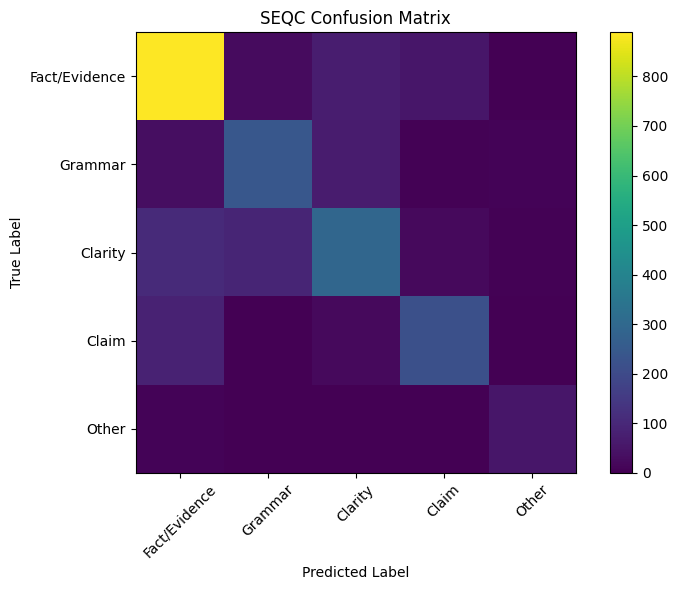

In [ ]:
#  confusion matrix

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

seqc_label_list = list(label2id.keys())

seqc_cm = confusion_matrix(seqc_true_names, seqc_pred_names, labels=seqc_label_list)

seqc_cm_df = pd.DataFrame(seqc_cm, index=seqc_label_list, columns=seqc_label_list)
print(seqc_cm_df)

plt.figure(figsize=(8, 6))
plt.imshow(seqc_cm, interpolation="nearest")
plt.title("SEQC Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(seqc_label_list)), seqc_label_list, rotation=45)
plt.yticks(range(len(seqc_label_list)), seqc_label_list)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
#  save SEQC model to Google Drive

from google.colab import drive
drive.mount('/content/drive')

seqc_save_path = "/content/drive/MyDrive/seqc_final_model"

seqc_trainer.save_model(seqc_save_path)
seqc_tokenizer.save_pretrained(seqc_save_path)

print("SEQC model saved at:", seqc_save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SEQC model saved at: /content/drive/MyDrive/seqc_final_model
